# Henalytics Egg Production Forecasting Using SARIMAX

This notebook uses the cleaned dataset:

```text
Egg_Production_Final_Cleaned.csv
```

### Forecast target

```python
TARGET_COLUMN = "Pieces"
```

### External predictors

```python
EXOG_COLUMNS = [
    "Bird No.",
    "Dead",
    "Cull",
    "FEED (bags)"
]
```

The notebook produces:

1. Egg-production time-series plots
2. Trend lines using rolling averages
3. Separate trends for each external predictor
4. Correlation and scatter analysis
5. Stationarity testing
6. SARIMAX model selection
7. Train-test evaluation using MAE, RMSE, and MAPE
8. Actual-versus-predicted plots
9. Future scenario forecasting
10. CSV export of predictions

> `%HD` and `%HH` are intentionally excluded from the predictors because they are closely derived from egg production and may cause target leakage.

## 1. Install packages if needed

Run this **inside a Jupyter cell**, not in Windows Command Prompt:

```python
%pip install pandas numpy matplotlib plotly statsmodels scikit-learn
```

In [1]:
import warnings
warnings.filterwarnings("ignore")

from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

## 2. Configuration

In [2]:
FILE_NAME = "Egg_Production_Final_Cleaned.csv"

DATE_COLUMN = "Corrected Date"
TARGET_COLUMN = "Pieces"

EXOG_COLUMNS = [
    "Bird No.",
    "Dead",
    "Cull",
    "FEED (bags)",
]

TEST_SIZE = 0.20
FORECAST_DAYS = 30

# Weekly seasonality for daily egg-production records.
SEASONAL_PERIOD = 7

# Search ranges. Keep these small first so the notebook runs reasonably fast.
P_VALUES = range(0, 3)
D_VALUES = range(0, 2)
Q_VALUES = range(0, 3)

SEASONAL_P_VALUES = range(0, 2)
SEASONAL_D_VALUES = range(0, 2)
SEASONAL_Q_VALUES = range(0, 2)

print("Dataset:", FILE_NAME)
print("Target:", TARGET_COLUMN)
print("External predictors:", EXOG_COLUMNS)
print("Seasonal period:", SEASONAL_PERIOD)

Dataset: Egg_Production_Final_Cleaned.csv
Target: Pieces
External predictors: ['Bird No.', 'Dead', 'Cull', 'FEED (bags)']
Seasonal period: 7


## 3. Read and inspect the cleaned dataset

In [3]:
file_path = Path(FILE_NAME)

if not file_path.exists():
    raise FileNotFoundError(
        f"{FILE_NAME} was not found. Place the CSV in the same folder as this notebook."
    )

raw_data = pd.read_csv(file_path)

print("Dataset shape:", raw_data.shape)
print("\nAvailable columns:")
print(raw_data.columns.tolist())

display(raw_data.head())
display(raw_data.tail())

Dataset shape: (312, 9)

Available columns:
['AGE Week', 'Corrected Date', 'Bird No.', 'Dead', 'Cull', 'Pieces', '%HD', '%HH', 'FEED (bags)']


,AGE Week,Corrected Date,Bird No.,Dead,Cull,Pieces,%HD,%HH,FEED (bags)
0,21,2024-10-19,1978,NaN,NaN,458,23.150,23.070,4.000
1,21,2024-10-20,1978,NaN,NaN,587,29.220,29.570,4.000
2,21,2024-10-21,1978,NaN,NaN,689,34.630,34.500,4.000
3,21,2024-10-22,1978,NaN,NaN,841,42.510,42.360,4.000
4,21,2024-10-23,1918,NaN,NaN,990,50.350,49.370,4.000


,AGE Week,Corrected Date,Bird No.,Dead,Cull,Pieces,%HD,%HH,FEED (bags)
307,65,2025-08-25,1747,NaN,NaN,1577,90.270,79.450,4.000
308,65,2025-08-26,1747,NaN,NaN,1585,90.730,79.850,4.000
309,65,2025-08-27,1747,NaN,NaN,1584,90.670,79.800,4.000
310,65,2025-08-28,1744,3.000,NaN,1572,90.140,79.190,4.000
311,65,2025-08-29,1741,NaN,3.000,1573,90.350,79.240,4.000


## 4. Validate and prepare the data

In [4]:
required_columns = [DATE_COLUMN, TARGET_COLUMN, *EXOG_COLUMNS]
missing_columns = [column for column in required_columns if column not in raw_data.columns]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}. "
        f"Available columns: {raw_data.columns.tolist()}"
    )

data = raw_data[required_columns].copy()

data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce")

for column in [TARGET_COLUMN, *EXOG_COLUMNS]:
    data[column] = pd.to_numeric(data[column], errors="coerce")

# Blank mortality and culling values normally mean no event was recorded.
data["Dead"] = data["Dead"].fillna(0)
data["Cull"] = data["Cull"].fillna(0)

# Flock count and feed are expected to remain at their latest recorded value
# until a new valid record appears.
data["Bird No."] = data["Bird No."].ffill()
data["FEED (bags)"] = data["FEED (bags)"].ffill()

invalid_required_rows = data[
    data[[DATE_COLUMN, TARGET_COLUMN, "Bird No.", "FEED (bags)"]]
    .isna()
    .any(axis=1)
].copy()

data = data.dropna(
    subset=[DATE_COLUMN, TARGET_COLUMN, "Bird No.", "FEED (bags)"]
)

data = data.sort_values(DATE_COLUMN)

# Average duplicate dates if they exist.
duplicate_count = int(data.duplicated(subset=[DATE_COLUMN]).sum())

aggregation_rules = {
    TARGET_COLUMN: "mean",
    "Bird No.": "mean",
    "Dead": "sum",
    "Cull": "sum",
    "FEED (bags)": "mean",
}

data = (
    data.groupby(DATE_COLUMN, as_index=False)
    .agg(aggregation_rules)
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

print(f"Invalid required rows excluded: {len(invalid_required_rows)}")
print(f"Duplicate dates combined: {duplicate_count}")
print(f"Valid observations: {len(data)}")
print(f"Date range: {data[DATE_COLUMN].min().date()} to {data[DATE_COLUMN].max().date()}")

display(data.head())

Invalid required rows excluded: 0
Duplicate dates combined: 0
Valid observations: 312
Date range: 2024-10-19 to 2025-08-29


,Corrected Date,Pieces,Bird No.,Dead,Cull,FEED (bags)
0,2024-10-19,458.000,"1,978.000",0.000,0.000,4.000
1,2024-10-20,587.000,"1,978.000",0.000,0.000,4.000
2,2024-10-21,689.000,"1,978.000",0.000,0.000,4.000
3,2024-10-22,841.000,"1,978.000",0.000,0.000,4.000
4,2024-10-23,990.000,"1,918.000",0.000,0.000,4.000


## 5. Check calendar gaps

SARIMAX requires equally spaced observations. This notebook does not invent missing egg-production values. Instead, it identifies uninterrupted daily sections and uses the longest continuous section for model training.

In [5]:
complete_calendar = pd.date_range(
    start=data[DATE_COLUMN].min(),
    end=data[DATE_COLUMN].max(),
    freq="D",
)

missing_dates = complete_calendar.difference(data[DATE_COLUMN])

print(f"Expected calendar days: {len(complete_calendar)}")
print(f"Recorded days: {len(data)}")
print(f"Missing calendar dates: {len(missing_dates)}")

if len(missing_dates):
    display(pd.DataFrame({"Missing Date": missing_dates}).head(30))
else:
    print("No calendar gaps were found.")

Expected calendar days: 315
Recorded days: 312
Missing calendar dates: 3


,Missing Date
0,2024-10-30
1,2024-10-31
2,2024-11-01


In [6]:
def longest_continuous_daily_segment(frame, date_column):
    ordered = frame.sort_values(date_column).reset_index(drop=True).copy()

    day_gap = ordered[date_column].diff().dt.days
    ordered["_segment_id"] = day_gap.ne(1).cumsum()

    summary = (
        ordered.groupby("_segment_id")
        .agg(
            Start_Date=(date_column, "min"),
            End_Date=(date_column, "max"),
            Observations=(date_column, "size"),
        )
        .sort_values("Observations", ascending=False)
        .reset_index()
    )

    selected_id = summary.iloc[0]["_segment_id"]

    selected = (
        ordered.loc[ordered["_segment_id"] == selected_id]
        .drop(columns="_segment_id")
        .set_index(date_column)
        .asfreq("D")
    )

    if selected.isna().any().any():
        raise ValueError(
            "The selected section still contains missing values. "
            "Review the source data before fitting SARIMAX."
        )

    return selected, summary.drop(columns="_segment_id")


model_data, segment_summary = longest_continuous_daily_segment(
    data,
    DATE_COLUMN,
)

print("Continuous sections, largest first:")
display(segment_summary)

print(f"Selected observations: {len(model_data)}")
print(f"Selected period: {model_data.index.min().date()} to {model_data.index.max().date()}")
print("Index frequency:", model_data.index.freq)

Continuous sections, largest first:


,Start_Date,End_Date,Observations
0,2024-11-02,2025-08-29,301
1,2024-10-19,2024-10-29,11


Selected observations: 301
Selected period: 2024-11-02 to 2025-08-29
Index frequency: <Day>


## 6. Egg-production time series and trend

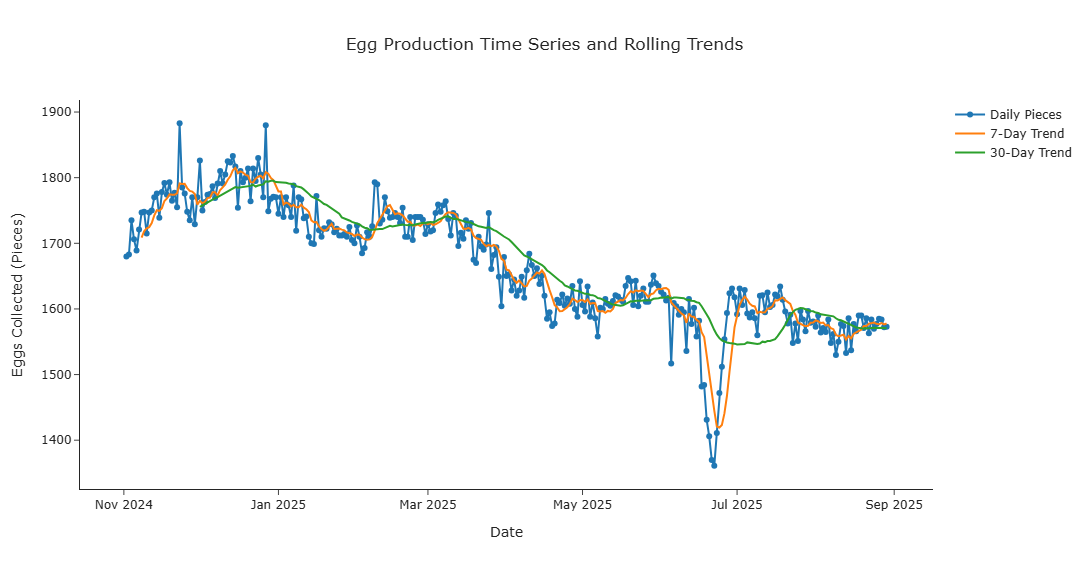

In [7]:
trend_data = model_data.copy()
trend_data["7-Day Trend"] = trend_data[TARGET_COLUMN].rolling(7).mean()
trend_data["30-Day Trend"] = trend_data[TARGET_COLUMN].rolling(30).mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=trend_data.index,
    y=trend_data[TARGET_COLUMN],
    mode="lines+markers",
    name="Daily Pieces",
))

fig.add_trace(go.Scatter(
    x=trend_data.index,
    y=trend_data["7-Day Trend"],
    mode="lines",
    name="7-Day Trend",
))

fig.add_trace(go.Scatter(
    x=trend_data.index,
    y=trend_data["30-Day Trend"],
    mode="lines",
    name="30-Day Trend",
))

fig.update_layout(
    title="Egg Production Time Series and Rolling Trends",
    xaxis_title="Date",
    yaxis_title="Eggs Collected (Pieces)",
    template="simple_white",
    title_x=0.5,
    width=1100,
    height=550,
    hovermode="x unified",
)

fig.show()

## 7. External predictor time-series trends

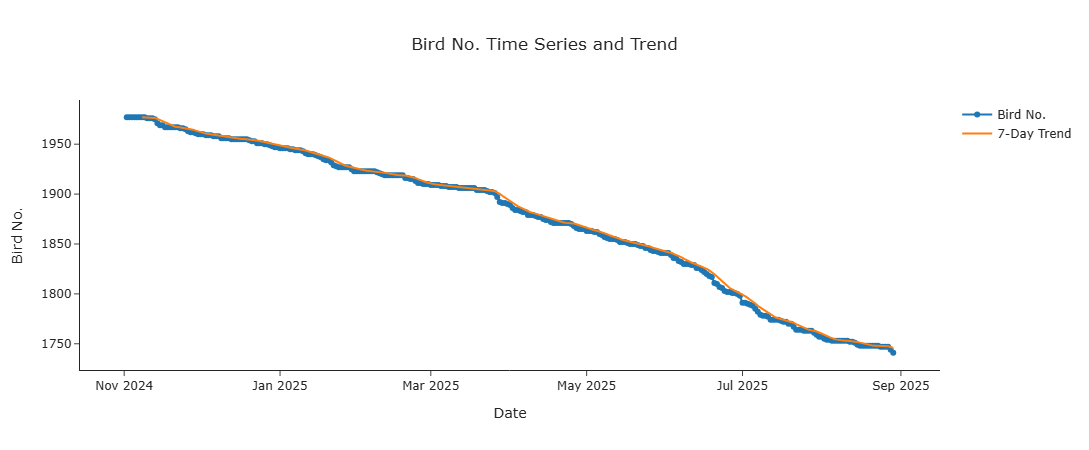

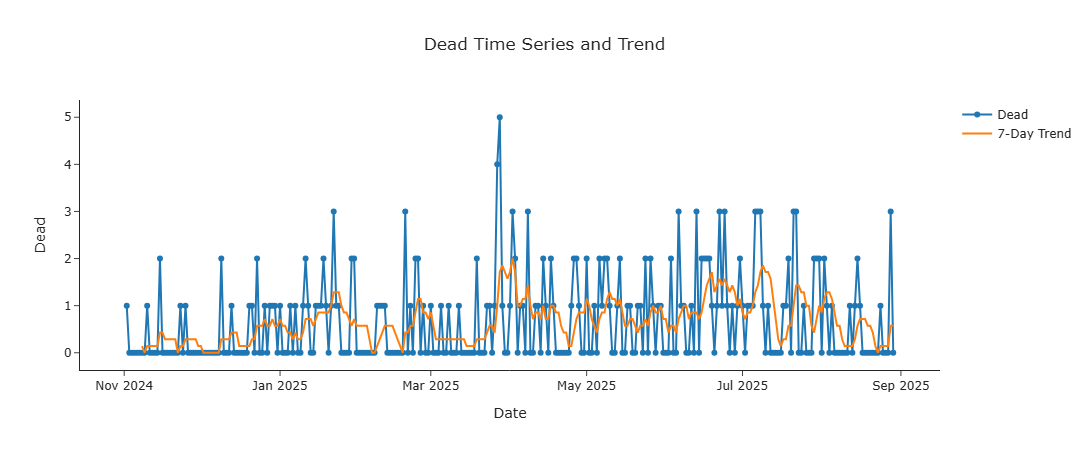

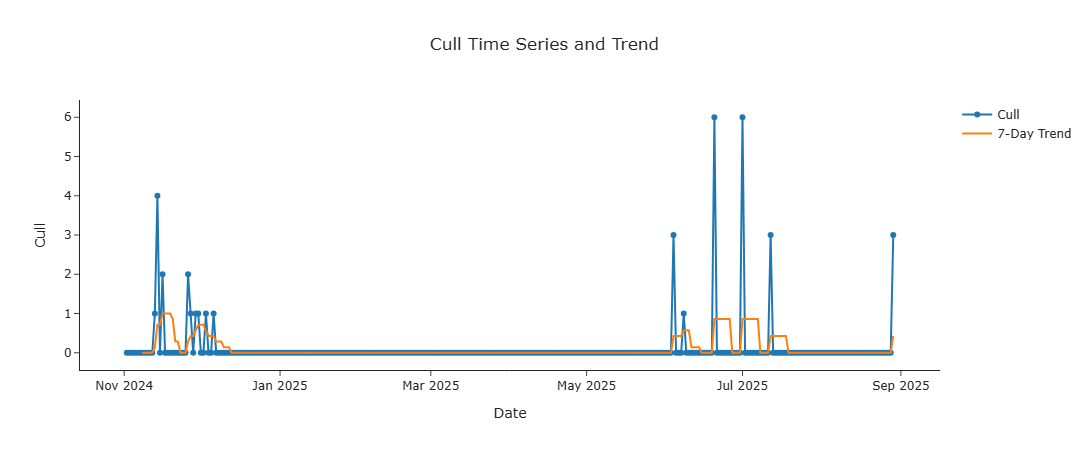

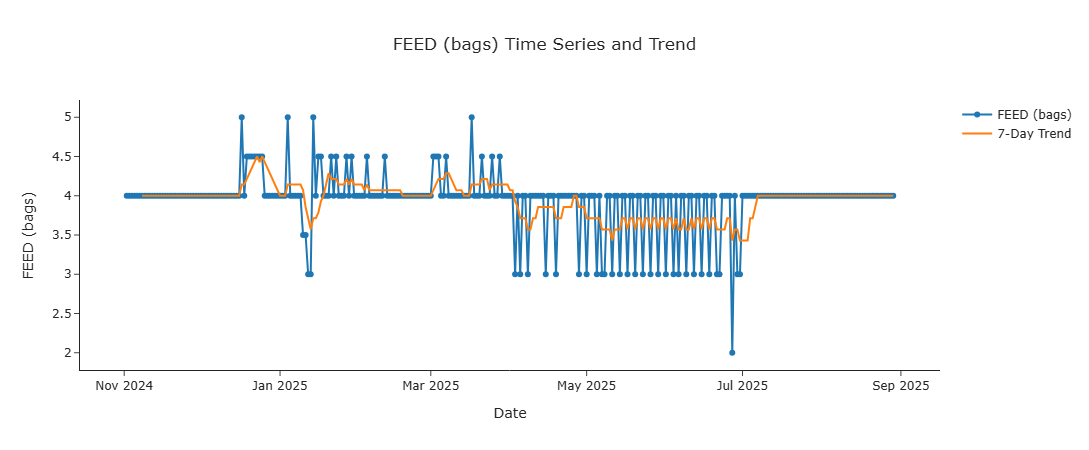

In [8]:
for column in EXOG_COLUMNS:
    plot_frame = model_data[[column]].copy()
    plot_frame["7-Day Trend"] = plot_frame[column].rolling(7).mean()

    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=plot_frame.index,
        y=plot_frame[column],
        mode="lines+markers",
        name=column,
    ))

    fig.add_trace(go.Scatter(
        x=plot_frame.index,
        y=plot_frame["7-Day Trend"],
        mode="lines",
        name="7-Day Trend",
    ))

    fig.update_layout(
        title=f"{column} Time Series and Trend",
        xaxis_title="Date",
        yaxis_title=column,
        template="simple_white",
        title_x=0.5,
        width=1050,
        height=450,
        hovermode="x unified",
    )

    fig.show()

## 8. Normalized comparison of target and predictors

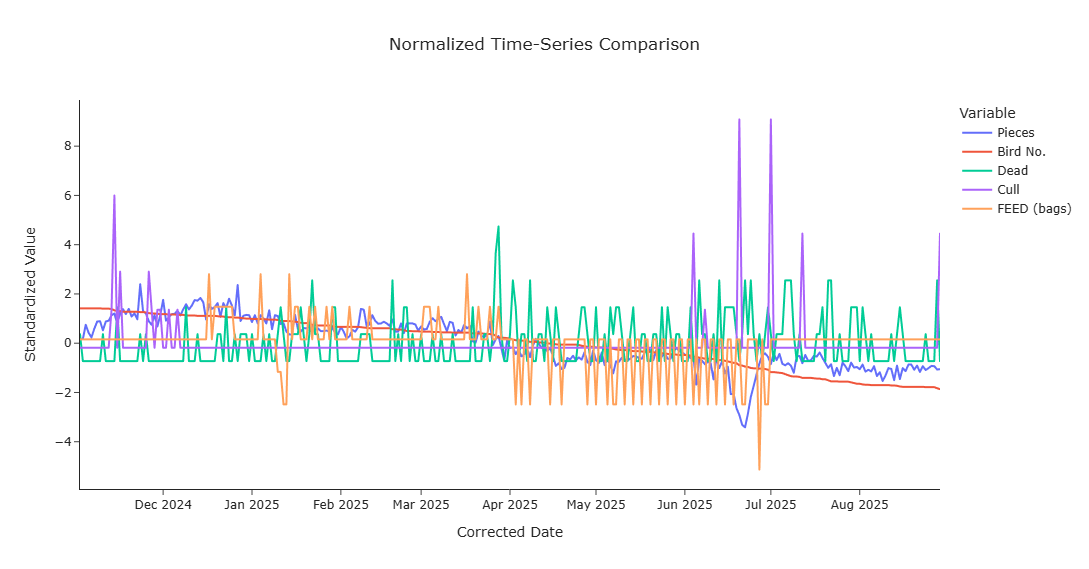

In [9]:
comparison_columns = [TARGET_COLUMN, *EXOG_COLUMNS]

normalized = model_data[comparison_columns].copy()

for column in comparison_columns:
    standard_deviation = normalized[column].std()

    if standard_deviation == 0:
        normalized[column] = 0
    else:
        normalized[column] = (
            normalized[column] - normalized[column].mean()
        ) / standard_deviation

normalized = normalized.reset_index().melt(
    id_vars=DATE_COLUMN,
    value_vars=comparison_columns,
    var_name="Variable",
    value_name="Standardized Value",
)

fig = px.line(
    normalized,
    x=DATE_COLUMN,
    y="Standardized Value",
    color="Variable",
    title="Normalized Time-Series Comparison",
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=1100,
    height=550,
    hovermode="x unified",
)

fig.show()

## 9. Correlation with egg production

In [10]:
correlation_matrix = model_data[
    [TARGET_COLUMN, *EXOG_COLUMNS]
].corr()

display(correlation_matrix)

target_correlations = (
    correlation_matrix[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=abs, ascending=False)
    .rename("Correlation with Pieces")
    .to_frame()
)

display(target_correlations)

,Pieces,Bird No.,Dead,Cull,FEED (bags)
Pieces,1.000,0.837,-0.241,-0.080,0.333
Bird No.,0.837,1.000,-0.182,-0.035,0.200
Dead,-0.241,-0.182,1.000,-0.095,-0.169
Cull,-0.080,-0.035,-0.095,1.000,-0.012
FEED (bags),0.333,0.200,-0.169,-0.012,1.000


,Correlation with Pieces
Bird No.,0.837
FEED (bags),0.333
Dead,-0.241
Cull,-0.080


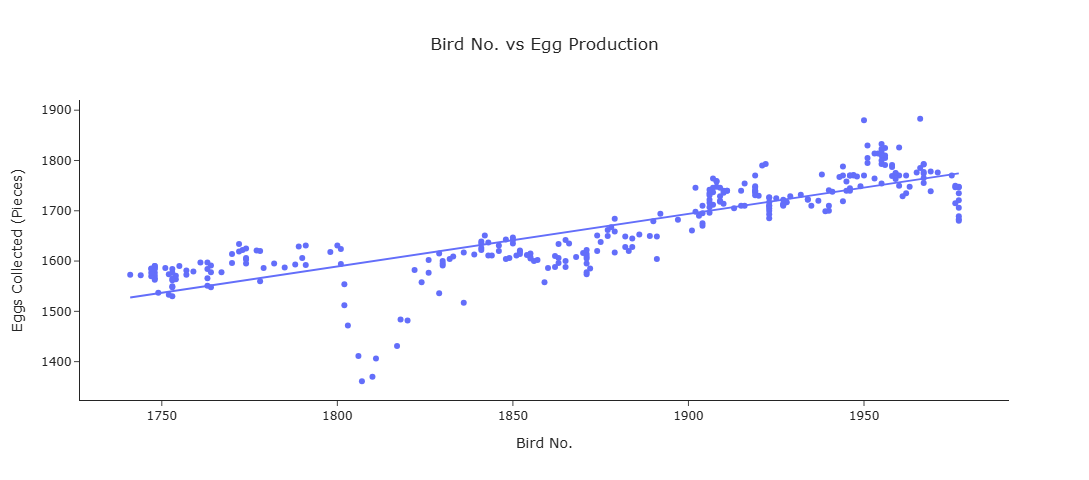

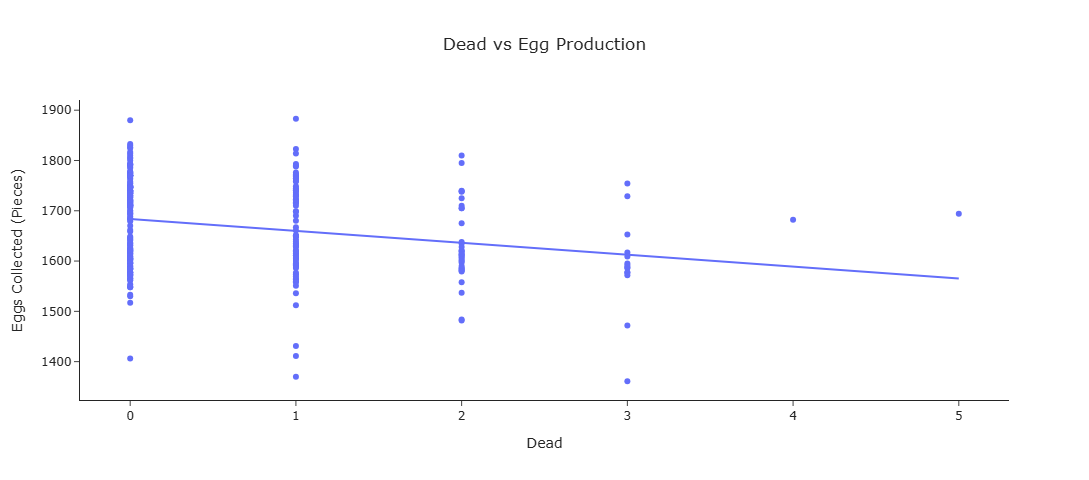

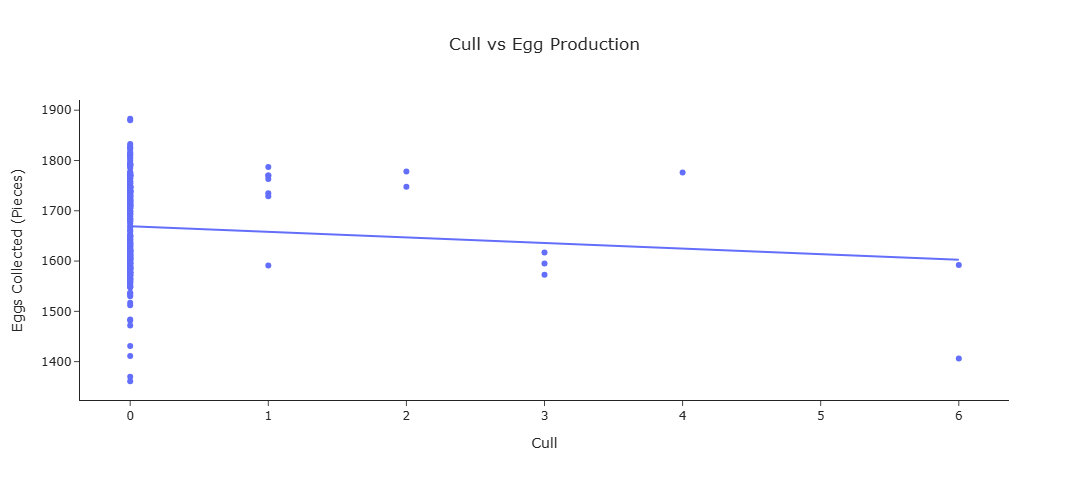

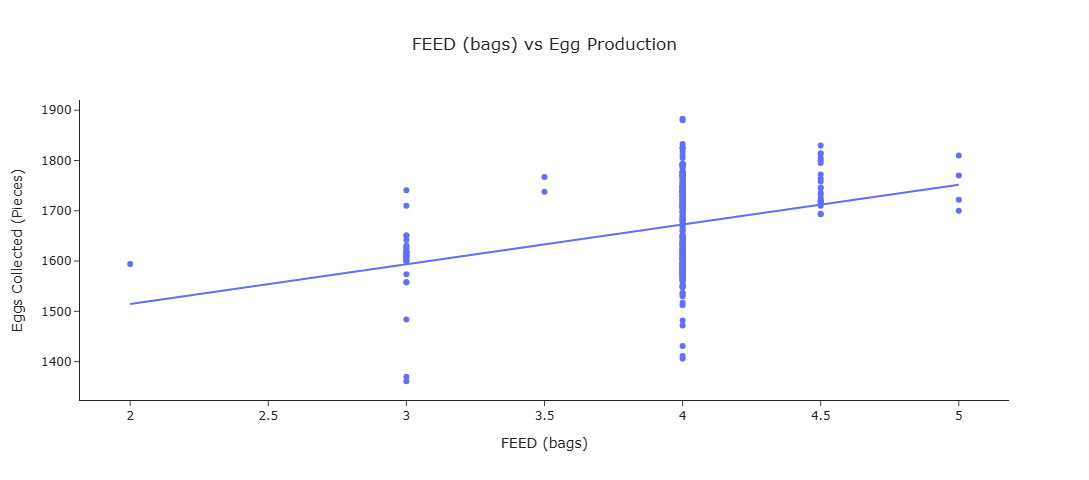

In [11]:
for column in EXOG_COLUMNS:
    fig = px.scatter(
        model_data.reset_index(),
        x=column,
        y=TARGET_COLUMN,
        trendline="ols",
        title=f"{column} vs Egg Production",
        labels={TARGET_COLUMN: "Eggs Collected (Pieces)"},
    )

    fig.update_layout(
        template="simple_white",
        title_x=0.5,
        width=800,
        height=480,
    )

    fig.show()

## 10. Stationarity test

In [12]:
def run_adf_test(series, label):
    clean_series = pd.Series(series).dropna()

    result = adfuller(clean_series, autolag="AIC")

    print(f"ADF test: {label}")
    print(f"ADF statistic: {result[0]:.6f}")
    print(f"p-value: {result[1]:.6f}")
    print(f"Lags used: {result[2]}")
    print(f"Observations: {result[3]}")

    if result[1] <= 0.05:
        print("Conclusion: stationary at the 5% significance level.")
    else:
        print("Conclusion: not stationary at the 5% significance level.")

    return result


target_series = model_data[TARGET_COLUMN].astype(float)

adf_original = run_adf_test(
    target_series,
    "Original Pieces series",
)

print()
adf_difference = run_adf_test(
    target_series.diff().dropna(),
    "First-differenced Pieces series",
)

ADF test: Original Pieces series
ADF statistic: -1.594473
p-value: 0.486369
Lags used: 2
Observations: 298
Conclusion: not stationary at the 5% significance level.

ADF test: First-differenced Pieces series
ADF statistic: -16.872597
p-value: 0.000000
Lags used: 1
Observations: 298
Conclusion: stationary at the 5% significance level.


## 11. ACF and PACF

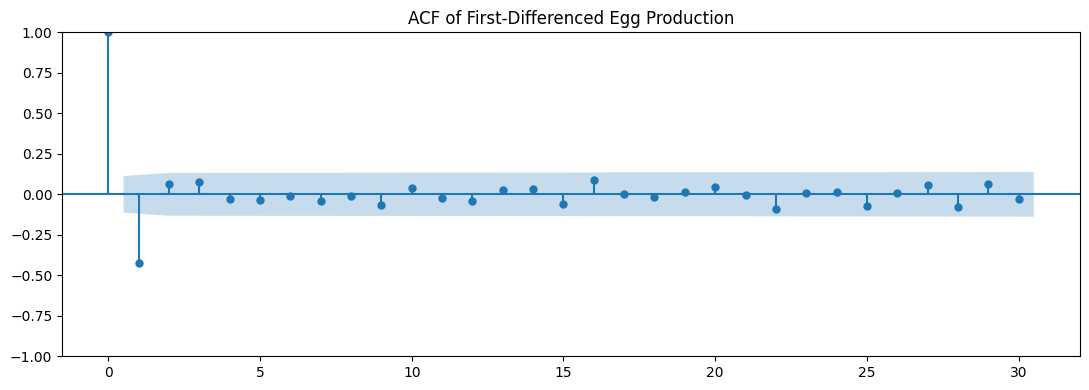

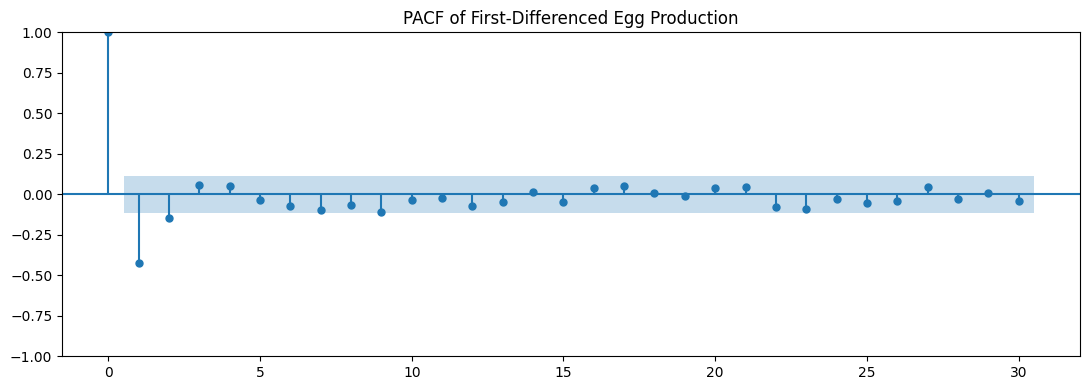

In [13]:
differenced_target = target_series.diff().dropna()
maximum_lags = min(30, max(5, len(differenced_target) // 3))

fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(differenced_target, lags=maximum_lags, ax=ax)
ax.set_title("ACF of First-Differenced Egg Production")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
plot_pacf(differenced_target, lags=maximum_lags, ax=ax, method="ywm")
ax.set_title("PACF of First-Differenced Egg Production")
plt.tight_layout()
plt.show()

## 12. Train-test split

In [14]:
test_count = max(14, int(round(len(model_data) * TEST_SIZE)))

if test_count >= len(model_data):
    raise ValueError("The selected test size is too large.")

train_data = model_data.iloc[:-test_count].copy()
test_data = model_data.iloc[-test_count:].copy()

y_train = train_data[TARGET_COLUMN].astype(float)
y_test = test_data[TARGET_COLUMN].astype(float)

x_train = train_data[EXOG_COLUMNS].astype(float)
x_test = test_data[EXOG_COLUMNS].astype(float)

print(f"Training observations: {len(train_data)}")
print(f"Testing observations: {len(test_data)}")
print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Testing period: {test_data.index.min().date()} to {test_data.index.max().date()}")

Training observations: 241
Testing observations: 60
Training period: 2024-11-02 to 2025-06-30
Testing period: 2025-07-01 to 2025-08-29


## 13. Automatic SARIMAX parameter search

This grid search compares combinations of:

- Non-seasonal order: `(p, d, q)`
- Seasonal order: `(P, D, Q, 7)`

The combination with the lowest AIC is selected.

In [15]:
def search_sarimax_orders(y, x):
    results = []

    regular_orders = list(product(P_VALUES, D_VALUES, Q_VALUES))
    seasonal_orders = list(
        product(
            SEASONAL_P_VALUES,
            SEASONAL_D_VALUES,
            SEASONAL_Q_VALUES,
        )
    )

    total_models = len(regular_orders) * len(seasonal_orders)
    completed = 0

    for order in regular_orders:
        for seasonal_part in seasonal_orders:
            seasonal_order = (
                seasonal_part[0],
                seasonal_part[1],
                seasonal_part[2],
                SEASONAL_PERIOD,
            )

            try:
                model = SARIMAX(
                    endog=y,
                    exog=x,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )

                fitted = model.fit(disp=False, maxiter=200)

                results.append({
                    "Order": order,
                    "Seasonal Order": seasonal_order,
                    "AIC": fitted.aic,
                    "BIC": fitted.bic,
                })
            except Exception:
                pass

            completed += 1

            if completed % 20 == 0 or completed == total_models:
                print(f"Checked {completed}/{total_models} models")

    if not results:
        raise RuntimeError(
            "No SARIMAX model could be fitted. "
            "Reduce the search ranges or review the dataset."
        )

    return (
        pd.DataFrame(results)
        .sort_values(["AIC", "BIC"])
        .reset_index(drop=True)
    )


search_results = search_sarimax_orders(y_train, x_train)

display(search_results.head(15))

best_order = tuple(search_results.iloc[0]["Order"])
best_seasonal_order = tuple(search_results.iloc[0]["Seasonal Order"])

print("Best non-seasonal order:", best_order)
print("Best seasonal order:", best_seasonal_order)

Checked 20/144 models
Checked 40/144 models
Checked 60/144 models


C:\Users\Gabriel Nicholas\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gabriel Nicholas\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Checked 80/144 models
Checked 100/144 models


C:\Users\Gabriel Nicholas\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Checked 120/144 models
Checked 140/144 models
Checked 144/144 models


,Order,Seasonal Order,AIC,BIC
0,"(2, 0, 2)","(0, 1, 1, 7)","2,184.022","2,218.138"
1,"(2, 0, 2)","(1, 1, 1, 7)","2,186.022","2,223.550"
2,"(1, 0, 2)","(0, 1, 1, 7)","2,187.685","2,218.390"
3,"(1, 0, 2)","(1, 1, 1, 7)","2,189.342","2,223.459"
4,"(0, 1, 2)","(0, 1, 1, 7)","2,192.138","2,219.395"
5,"(0, 1, 2)","(1, 1, 1, 7)","2,193.659","2,224.324"
6,"(2, 1, 2)","(0, 1, 1, 7)","2,193.670","2,227.742"
7,"(2, 1, 2)","(1, 1, 1, 7)","2,195.342","2,232.821"
8,"(1, 1, 2)","(0, 1, 1, 7)","2,196.219","2,226.884"
9,"(1, 1, 2)","(1, 1, 1, 7)","2,197.868","2,231.940"


Best non-seasonal order: (2, 0, 2)
Best seasonal order: (0, 1, 1, 7)


## 14. Fit and evaluate the selected SARIMAX model

In [16]:
evaluation_model = SARIMAX(
    endog=y_train,
    exog=x_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

evaluation_result = evaluation_model.fit(
    disp=False,
    maxiter=300,
)

print(evaluation_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              Pieces   No. Observations:                  241
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 7)   Log Likelihood               -1082.011
Date:                             Thu, 30 Jul 2026   AIC                           2184.022
Time:                                     02:48:47   BIC                           2218.138
Sample:                                 11-02-2024   HQIC                          2197.793
                                      - 06-30-2025                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Bird No.        1.5717      0.153     10.249      0.000       1.271       1.872
Dead            1.1948  

In [17]:
prediction_result = evaluation_result.get_forecast(
    steps=len(y_test),
    exog=x_test,
)

predictions = pd.Series(
    prediction_result.predicted_mean.to_numpy(),
    index=y_test.index,
    name="Predicted Pieces",
).clip(lower=0)

confidence = prediction_result.conf_int(alpha=0.05)

lower_bound = pd.Series(
    confidence.iloc[:, 0].to_numpy(),
    index=y_test.index,
).clip(lower=0)

upper_bound = pd.Series(
    confidence.iloc[:, 1].to_numpy(),
    index=y_test.index,
).clip(lower=0)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

nonzero_mask = y_test != 0
mape = (
    np.abs(
        (y_test[nonzero_mask] - predictions[nonzero_mask])
        / y_test[nonzero_mask]
    ).mean() * 100
    if nonzero_mask.any()
    else np.nan
)

metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae, rmse, mape],
})

display(metrics)

print(f"MAE: {mae:,.2f} eggs")
print(f"RMSE: {rmse:,.2f} eggs")
print(f"MAPE: {mape:,.2f}%" if not np.isnan(mape) else "MAPE: unavailable")

,Metric,Value
0,MAE,109.558
1,RMSE,113.036
2,MAPE,6.914


MAE: 109.56 eggs
RMSE: 113.04 eggs
MAPE: 6.91%


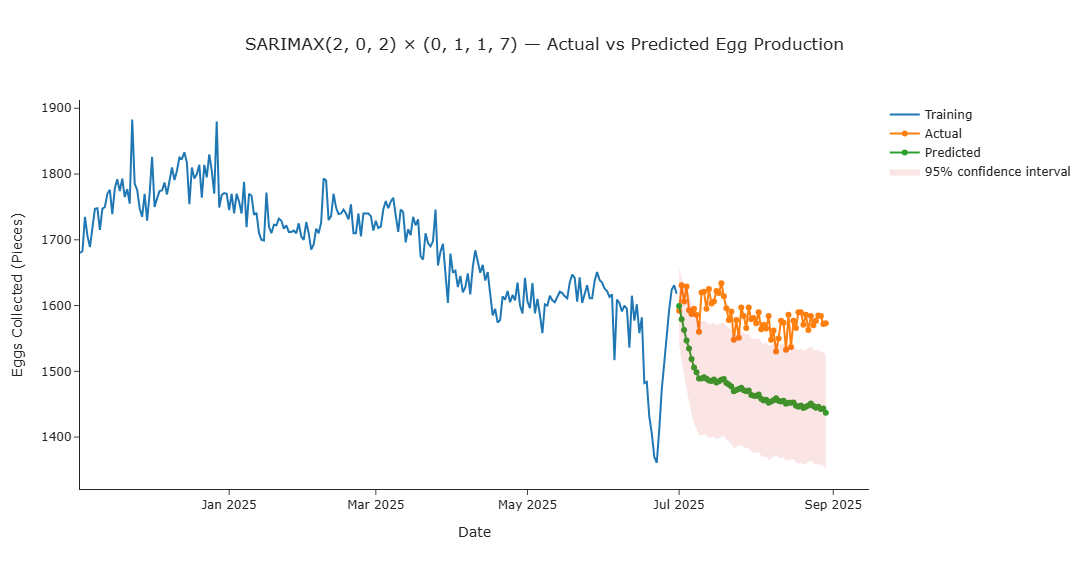

In [18]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_train.index,
    y=y_train.values,
    mode="lines",
    name="Training",
))

fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test.values,
    mode="lines+markers",
    name="Actual",
))

fig.add_trace(go.Scatter(
    x=predictions.index,
    y=predictions.values,
    mode="lines+markers",
    name="Predicted",
))

fig.add_trace(go.Scatter(
    x=list(upper_bound.index) + list(lower_bound.index[::-1]),
    y=list(upper_bound.values) + list(lower_bound.values[::-1]),
    fill="toself",
    line=dict(width=0),
    name="95% confidence interval",
    opacity=0.25,
    hoverinfo="skip",
))

fig.update_layout(
    title=(
        f"SARIMAX{best_order} × {best_seasonal_order} "
        "— Actual vs Predicted Egg Production"
    ),
    xaxis_title="Date",
    yaxis_title="Eggs Collected (Pieces)",
    template="simple_white",
    title_x=0.5,
    width=1100,
    height=550,
)

fig.show()

## 15. Residual diagnostics

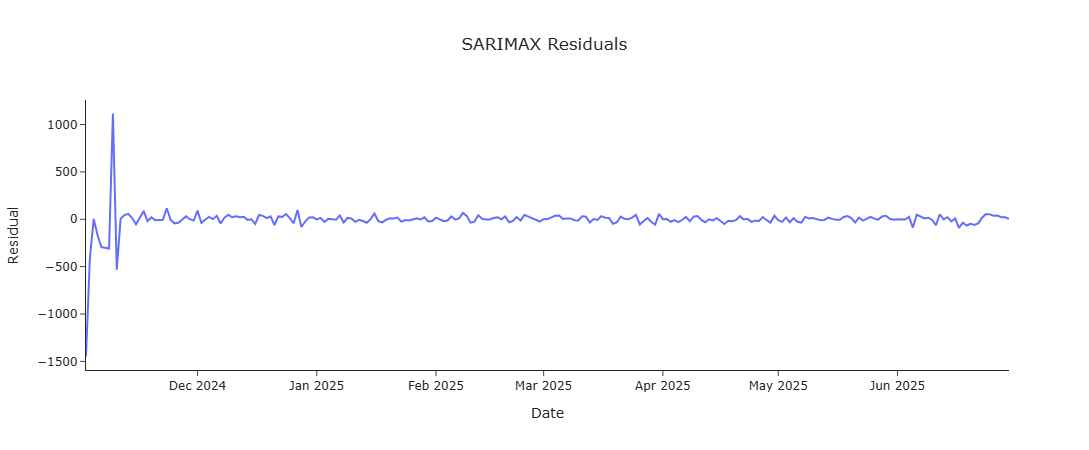

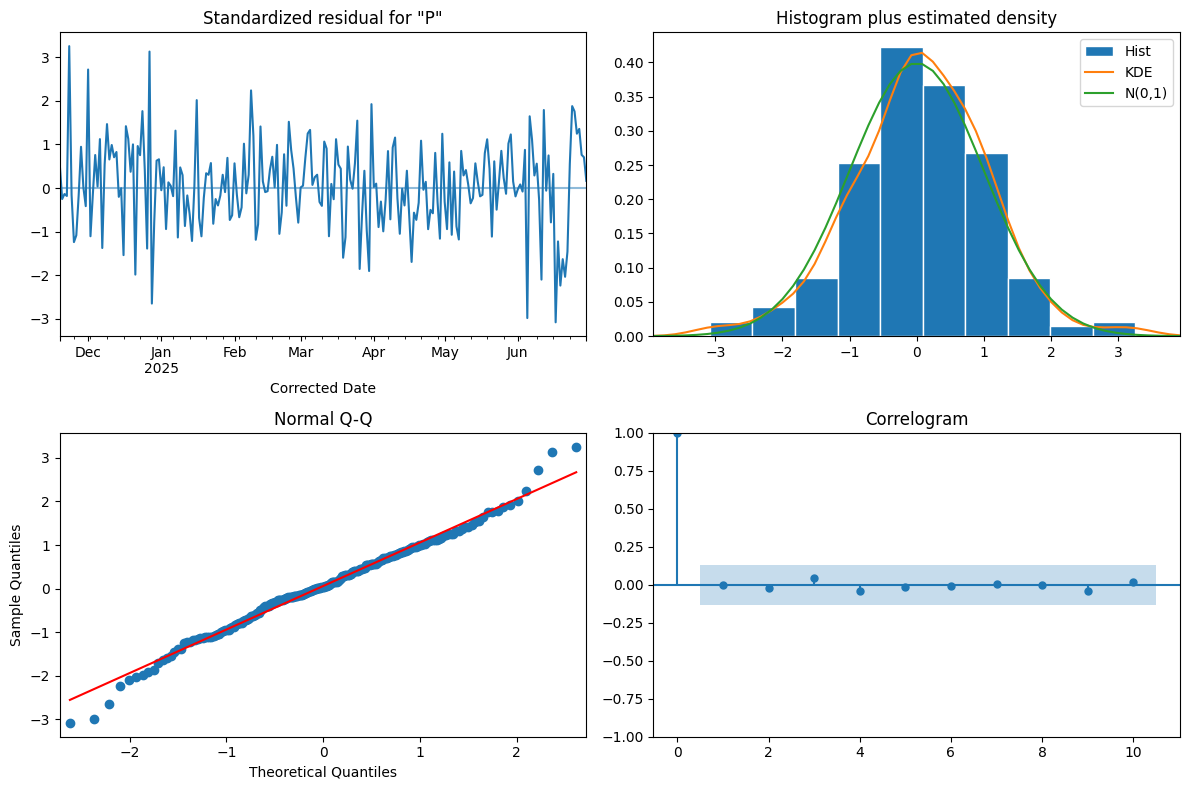

In [19]:
residuals = evaluation_result.resid.dropna()

fig = px.line(
    x=residuals.index,
    y=residuals.values,
    title="SARIMAX Residuals",
    labels={"x": "Date", "y": "Residual"},
)

fig.update_layout(
    template="simple_white",
    title_x=0.5,
    width=1000,
    height=450,
)

fig.show()

evaluation_result.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

## 16. Fit the final model using all selected observations

In [20]:
final_y = model_data[TARGET_COLUMN].astype(float)
final_x = model_data[EXOG_COLUMNS].astype(float)

final_model = SARIMAX(
    endog=final_y,
    exog=final_x,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

final_result = final_model.fit(
    disp=False,
    maxiter=300,
)

print(final_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              Pieces   No. Observations:                  301
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 7)   Log Likelihood               -1357.051
Date:                             Thu, 30 Jul 2026   AIC                           2734.102
Time:                                     02:48:52   BIC                           2770.592
Sample:                                 11-02-2024   HQIC                          2748.732
                                      - 08-29-2025                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Bird No.        1.0730      0.216      4.958      0.000       0.649       1.497
Dead            0.3968  

## 17. Prepare future predictor assumptions

SARIMAX requires future values for every external predictor.

The default scenario below assumes:

- `Bird No.` remains at the latest recorded value
- `Dead` is 0
- `Cull` is 0
- `FEED (bags)` remains at the latest recorded value

You can change these values to represent your actual farm plan or another scenario.

In [21]:
last_record = model_data.iloc[-1]

future_dates = pd.date_range(
    start=model_data.index.max() + pd.Timedelta(days=1),
    periods=FORECAST_DAYS,
    freq="D",
)

future_exog = pd.DataFrame(
    {
        "Bird No.": float(last_record["Bird No."]),
        "Dead": 0.0,
        "Cull": 0.0,
        "FEED (bags)": float(last_record["FEED (bags)"]),
    },
    index=future_dates,
)

print("Future predictor assumptions:")
display(future_exog.head())
display(future_exog.tail())

Future predictor assumptions:


,Bird No.,Dead,Cull,FEED (bags)
2025-08-30,"1,741.000",0.000,0.000,4.000
2025-08-31,"1,741.000",0.000,0.000,4.000
2025-09-01,"1,741.000",0.000,0.000,4.000
2025-09-02,"1,741.000",0.000,0.000,4.000
2025-09-03,"1,741.000",0.000,0.000,4.000


,Bird No.,Dead,Cull,FEED (bags)
2025-09-24,"1,741.000",0.000,0.000,4.000
2025-09-25,"1,741.000",0.000,0.000,4.000
2025-09-26,"1,741.000",0.000,0.000,4.000
2025-09-27,"1,741.000",0.000,0.000,4.000
2025-09-28,"1,741.000",0.000,0.000,4.000


## 18. Generate the future forecast

In [22]:
future_result = final_result.get_forecast(
    steps=FORECAST_DAYS,
    exog=future_exog,
)

future_mean = future_result.predicted_mean.clip(lower=0)
future_confidence = future_result.conf_int(alpha=0.05)

forecast_table = pd.DataFrame({
    "Date": future_dates,
    "Forecast Pieces": future_mean.to_numpy(),
    "Lower 95% CI": future_confidence.iloc[:, 0].clip(lower=0).to_numpy(),
    "Upper 95% CI": future_confidence.iloc[:, 1].clip(lower=0).to_numpy(),
    "Assumed Bird No.": future_exog["Bird No."].to_numpy(),
    "Assumed Dead": future_exog["Dead"].to_numpy(),
    "Assumed Cull": future_exog["Cull"].to_numpy(),
    "Assumed Feed Bags": future_exog["FEED (bags)"].to_numpy(),
})

forecast_table[
    ["Forecast Pieces", "Lower 95% CI", "Upper 95% CI"]
] = forecast_table[
    ["Forecast Pieces", "Lower 95% CI", "Upper 95% CI"]
].round(0).astype(int)

display(forecast_table)

,Date,Forecast Pieces,Lower 95% CI,Upper 95% CI,Assumed Bird No.,Assumed Dead,Assumed Cull,Assumed Feed Bags
0,2025-08-30,1572,1517,1627,"1,741.000",0.000,0.000,4.000
1,2025-08-31,1565,1505,1624,"1,741.000",0.000,0.000,4.000
2,2025-09-01,1559,1490,1627,"1,741.000",0.000,0.000,4.000
3,2025-09-02,1557,1481,1633,"1,741.000",0.000,0.000,4.000
4,2025-09-03,1548,1467,1630,"1,741.000",0.000,0.000,4.000
5,2025-09-04,1549,1463,1634,"1,741.000",0.000,0.000,4.000
6,2025-09-05,1547,1458,1635,"1,741.000",0.000,0.000,4.000
7,2025-09-06,1547,1456,1637,"1,741.000",0.000,0.000,4.000
8,2025-09-07,1540,1448,1633,"1,741.000",0.000,0.000,4.000
9,2025-09-08,1537,1444,1631,"1,741.000",0.000,0.000,4.000


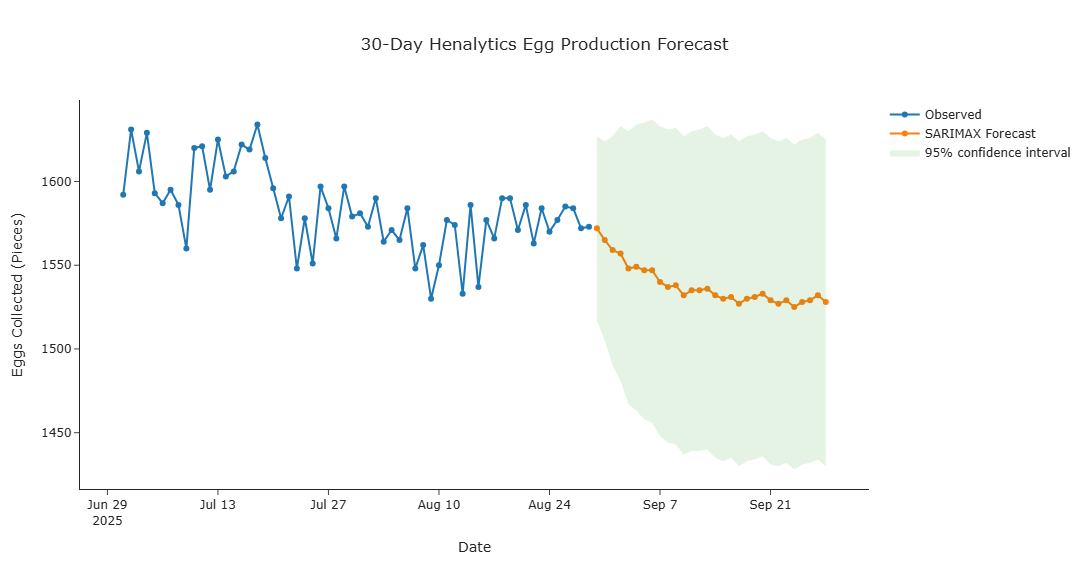

In [23]:
recent_actual = final_y.tail(min(60, len(final_y)))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recent_actual.index,
    y=recent_actual.values,
    mode="lines+markers",
    name="Observed",
))

fig.add_trace(go.Scatter(
    x=forecast_table["Date"],
    y=forecast_table["Forecast Pieces"],
    mode="lines+markers",
    name="SARIMAX Forecast",
))

fig.add_trace(go.Scatter(
    x=list(forecast_table["Date"]) + list(forecast_table["Date"][::-1]),
    y=list(forecast_table["Upper 95% CI"])
      + list(forecast_table["Lower 95% CI"][::-1]),
    fill="toself",
    line=dict(width=0),
    name="95% confidence interval",
    opacity=0.25,
    hoverinfo="skip",
))

fig.update_layout(
    title=f"{FORECAST_DAYS}-Day Henalytics Egg Production Forecast",
    xaxis_title="Date",
    yaxis_title="Eggs Collected (Pieces)",
    template="simple_white",
    title_x=0.5,
    width=1100,
    height=550,
)

fig.show()

## 19. Export model outputs

In [24]:
FORECAST_OUTPUT_FILE = "Henalytics_SARIMAX_Forecast.csv"
EVALUATION_OUTPUT_FILE = "Henalytics_SARIMAX_Test_Predictions.csv"

forecast_table.to_csv(
    FORECAST_OUTPUT_FILE,
    index=False,
)

evaluation_table = pd.DataFrame({
    "Date": y_test.index,
    "Actual Pieces": y_test.to_numpy(),
    "Predicted Pieces": predictions.to_numpy(),
    "Lower 95% CI": lower_bound.to_numpy(),
    "Upper 95% CI": upper_bound.to_numpy(),
})

evaluation_table.to_csv(
    EVALUATION_OUTPUT_FILE,
    index=False,
)

print("Saved:", FORECAST_OUTPUT_FILE)
print("Saved:", EVALUATION_OUTPUT_FILE)

Saved: Henalytics_SARIMAX_Forecast.csv
Saved: Henalytics_SARIMAX_Test_Predictions.csv


## Important interpretation notes

- SARIMAX uses both historical egg production and the selected external predictors.
- Correlation does not prove that a predictor causes egg production changes.
- `Dead` and `Cull` blanks are treated as zero events.
- `%HD` and `%HH` are excluded to reduce target leakage.
- Missing calendar dates are not fabricated.
- The model uses the longest uninterrupted daily segment.
- Future forecasts depend on the assumptions supplied for flock size, mortality, culling, and feed.
- Replace the default future assumptions with real planned values before using forecasts for operational decisions.